# 실습 1: 이미지 분류

## 1) Ultralytics 버전

In [ ]:
# 설치 uv pip install git+https://

### 모델 불러오기

In [ ]:
import clip
import torch
from PIL import Image

from lib.utils.device import available_device

device = available_device()

model, processes = clip.load('ViT-B/32', device=device)

using cuda


### 이미지/텍스트 준비하기

In [4]:
from lib.utils.path import images_path

image_path = images_path() / 'badugi.jpg'
classes = ['a person', 'a car', 'a dog', 'a cat']

img = Image.open(image_path)

### 모델에 넣을 준비

In [7]:
image = processes(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

### 유사도 계산하기

In [20]:
with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image)
    print('=' * 20)
    print(_)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    print('=' * 20)
    print(probs)

tensor([[22.6250, 19.6406, 26.9219, 22.5469]], device='cuda:0',
       dtype=torch.float16)
tensor([[22.6250],
        [19.6406],
        [26.9219],
        [22.5469]], device='cuda:0', dtype=torch.float16)
[1.325e-02 6.704e-04 9.736e-01 1.226e-02]


### 결과

In [17]:
for label, prob in zip(classes, probs, strict=False):
    print(f'{label}: {prob:.4f}')

a person: 0.0133
a car: 0.0007
a dog: 0.9736
a cat: 0.0123


In [ ]:
probs_test = torch.tensor([1.325e-02, 6.704e-04, 9.736e-01, 1.226e-02])
classes = ['a person', 'a car', 'a dog', 'a cat']

print(probs_test.argmax())
print(classes[probs_test.argmax()])

tensor(2)
a dog


In [23]:
print(1.325e-02, 9.736e-01)

0.01325 0.9736


#### unsqueeze란?

In [12]:
import torch

x1 = torch.tensor([1.0, 2.0, 3.0])
print(x1)
print(x1.shape)

x2 = x1.unsqueeze(0)
print(x2)
print(x2.shape)

tensor([1., 2., 3.])
torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


## 2) HuggingFace 버전

### 모델 불러오기

In [24]:
import requests
from transformers import CLIPModel, CLIPProcessor

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### 이미지/텍스트 준비하기

In [38]:
from PIL import Image

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
classes = ['a photo of a cat', 'a photo of a dog']

### 모델에 넣을 준비

In [39]:
inputs = processor(
    text=classes,
    images=image,
    return_tensors='pt',
    padding=True,
)

### 유사도 계산

In [ ]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(
    dim=1
)  # we can take the softmax to get the label probabilities

In [31]:
print(probs)

tensor([[0.9948, 0.0052]], grad_fn=<SoftmaxBackward0>)


In [35]:
print(probs.squeeze(0))

tensor([0.9948, 0.0052], grad_fn=<SqueezeBackward1>)


In [30]:
for label, prob in zip(classes, probs[0], strict=False):
    print(f'{label}: {prob:.4f}')

a person: 0.9948
a car: 0.0052


In [41]:
index = probs[0].argmax()
print(index)
name = classes[index]
print(name)

tensor(0)
a photo of a cat


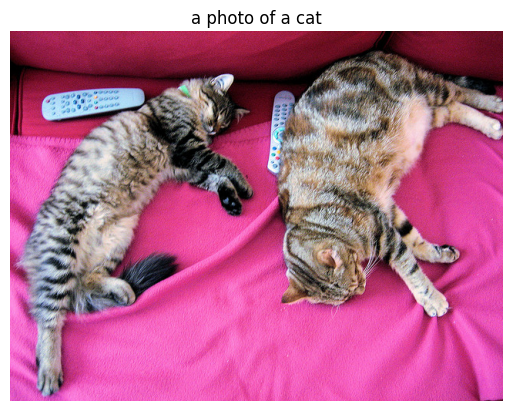

In [42]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(name)
plt.axis('off')
plt.show()

# 실습 2: 이미지 검색

### 모델 불러오기

In [1]:
from transformers import CLIPModel, CLIPProcessor

from lib.utils.device import available_device

device = available_device()

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

using cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


### 검색 대상 폴더 불어오기

In [2]:
import os

from lib.utils.path import images_path

image_folder = images_path() / 'clothes'
files = []

allow_extensions = ['jpg', 'jpeg', 'png']
for file in os.listdir(image_folder):
    if file.split('.')[-1] in allow_extensions:
        files.append(os.path.join(image_folder, file))

print(files)

['c:\\Workspaces\\model_lab\\data\\images\\clothes\\image1.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image2.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image3.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image4.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image5.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\sit.jpg']


### 폴더 이미지 벡터화 하기

In [3]:
import torch
from PIL import Image

image_features = []

for file in files:
    image = Image.open(file)
    inputs = processor(images=image, return_tensors='pt').to(device)

    with torch.no_grad():
        feature = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        feature = model.visual_projection(feature)
        feature /= feature.norm(dim=-1, keepdim=True)

    image_features.append(feature.cpu())

image_features = torch.cat(image_features, dim=0)

In [13]:
# cat 예시
feat1 = torch.tensor([[1.0, 2.0, 3.0]])
feat2 = torch.tensor([[4.0, 5.0, 6.0]])

features = [feat1, feat2]
print(features)

features_cat = torch.cat(features, dim=0)
print(features_cat)

[tensor([[1., 2., 3.]]), tensor([[4., 5., 6.]])]
tensor([[1., 2., 3.],
        [4., 5., 6.]])


### 검색하기

In [18]:
query = 'a blue shirt'
query = 'a black shirt'
top_k = 3

In [19]:
# 텍스트 벡터화
inputs = processor(text=[query], return_tensors='pt').to(device)

with torch.no_grad():
    text_feature = model.text_model(
        input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask']
    ).pooler_output

    text_feature = model.text_projection(text_feature)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

In [20]:
# 유사도 계산
similarity = (image_features @ text_feature.cpu().T).squeeze(1)  # cos 유사도 공식
top_indices = similarity.argsort(descending=True)[:top_k]  # 정렬 순서를 위치로 반환

print(similarity)
print(files)
print(top_indices)

tensor([0.2236, 0.2327, 0.2827, 0.2399, 0.2430, 0.2113])
['c:\\Workspaces\\model_lab\\data\\images\\clothes\\image1.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image2.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image3.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image4.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\image5.jpg', 'c:\\Workspaces\\model_lab\\data\\images\\clothes\\sit.jpg']
tensor([2, 4, 3])


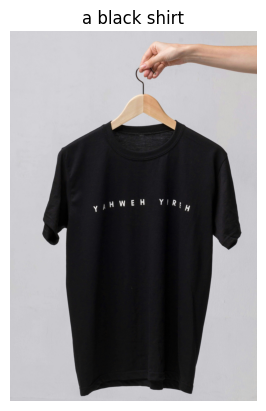

In [21]:
import matplotlib.pyplot as plt

img = Image.open(files[2])

plt.imshow(img)
plt.title(query)
plt.axis('off')
plt.show()

# 실습 3: 모델 유합(YOLO + CLIP)

In [22]:
# 나는 이미지에서 사람이 앉아있는지 아닌지를 분류하고 싶습니다.
# sit.jpg
# YOLO로 사람 찾기
# CLIP 1을 활용해서 사람 분류하기

### 모델 불러오기

In [23]:
from ultralytics import YOLO

from lib.utils.path import model_path

yolo_model = YOLO(model_path('yolo26n.pt'))

In [24]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
from lib.utils.device import available_device

device = available_device()

yolo_model.to(device)
clip_model.to(device)

using cuda


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

### 이미지/텍스트 준비하기

In [26]:
from PIL import Image

from lib.utils.path import images_path

image_path = images_path() / 'sit.jpg'
classes = ['a person standing', 'a person sitting']

### YOLO로 객체 감지하기

In [27]:
yolo_pred = yolo_model(source=image_path)[0]
yolo_pred


image 1/1 c:\Workspaces\model_lab\data\images\sit.jpg: 640x512 1 person, 75.2ms
Speed: 6.2ms preprocess, 75.2ms inference, 25.8ms postprocess per image at shape (1, 3, 640, 512)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [30]:
names = yolo_pred.names
boxes = yolo_pred.boxes

persons = []

for data in boxes.data:
    x1, y1, x2, y2, conf, idx = data.cpu()
    if names[int(idx)] == 'person':
        persons.append(data.cpu())

### 객체 감지한 결과에서 CLIP으로 분류하기

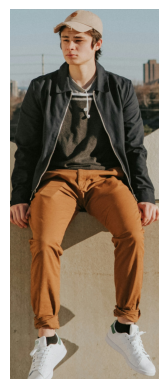

In [36]:
import matplotlib.pyplot as plt

x1, y1, x2, y2, conf, idx = persons[0]
crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

plt.imshow(crop_image)
plt.axis('off')
plt.show()

In [33]:
from PIL import Image

image = Image.open(image_path)

for data in persons:
    x1, y1, x2, y2, conf, idx = data
    crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

    inputs = processor(
        text=classes, images=crop_image, return_tensors='pt', padding=True
    ).to(device)

    with torch.no_grad():
        output = clip_model(**inputs)
        logits_per_image = output.logits_per_image
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    best = classes[probs.argmax()]
    print(f'{best} {probs.max(): .4f}')

a person sitting  0.5386


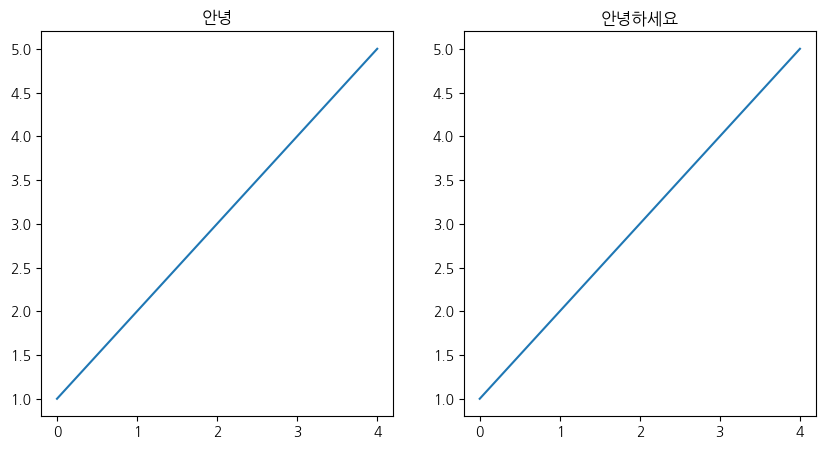

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

font_path = 'C:/Windows/Fonts/malgun.ttf'

font_manager.fontManager.addfont(font_path)
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot([1, 2, 3, 4, 5])
axes[0].set_title('안녕')

axes[1].plot([1, 2, 3, 4, 5])
axes[1].set_title('안녕하세요')

plt.show()